# Challenge A

In [151]:
import numpy as np
import matplotlib.pyplot as plt
import random

def metrics(y_true, y_pred):
    # Mean Squared Error (MSE)
    mse = np.mean((y_true - y_pred)**2)
    # R-squared value
    ss_total = np.sum((y_true - np.mean(y_true))**2)
    ss_res = np.sum((y_true - y_pred)**2)
    r_squared = 1 - (ss_res / ss_total)
    
    return mse, r_squared

Linear LSQ - MSE: 9.746550144726825, R2: 0.006689266135723737
Cubic Polyfit - MSE: 4.994387643218276, R2: 0.49100155630227216
The better fit is: Cubic Polyfit


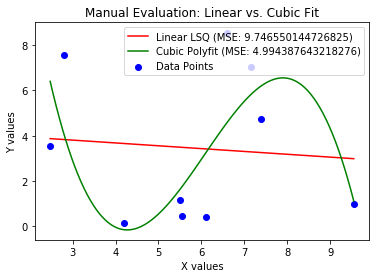

In [152]:
#data
x_values = 10 * np.sort(np.random.rand(10))
y_values = 10 * np.random.rand(10)

#solve with lsqr
A = np.vstack([x_values, np.ones(len(x_values))]).T
m, c = np.linalg.lstsq(A, y_values, rcond=None)[0]
y_pred_lsqr = m * x_values + c

#solve with polyfit
poly_coeffs = np.polyfit(x_values, y_values, 3)
p_cubic = np.poly1d(poly_coeffs)
y_pred_poly = p_cubic(x_values)

#metrics of methods
mse_lsqr, r2_lsqr = metrics(y_values, y_pred_lsqr)
mse_poly, r2_poly = metrics(y_values, y_pred_poly)

#Determining better fit
if mse_poly<mse_lsqr:
    better_method = "Cubic Polyfit"
else:
    better_method = "Linear Least Squares"

#graphing
plt.scatter(x_values, y_values, color='blue', label='Data Points')

x_range = np.linspace(x_values.min(), x_values.max(), 100)
plt.plot(x_range, m * x_range + c, color='red', label=f'Linear LSQ (MSE: {mse_lsqr})')
plt.plot(x_range, p_cubic(x_range), color='green', label=f'Cubic Polyfit (MSE: {mse_poly})')
plt.xlabel('X values')
plt.ylabel('Y values')
plt.title('Manual Evaluation: Linear vs. Cubic Fit')
plt.legend()

#evaluation
print(f"Linear LSQ - MSE: {mse_lsqr}, R2: {r2_lsqr}")
print(f"Cubic Polyfit - MSE: {mse_poly}, R2: {r2_poly}")
print(f"The better fit is: {better_method}")

# Challenge B

Degree   | MSE          | R-Squared  | Status
------------------------------------------------------------
1        |       9.7466 |     0.0067 | Underfit
2        |       9.7303 |     0.0083 | Underfit
3        |       4.9944 |     0.4910 | Underfit
4        |       4.2203 |     0.5699 | Underfit
5        |       1.9817 |     0.7980 | Reasonable
6        |       1.8855 |     0.8078 | Reasonable
7        |       0.8593 |     0.9124 | Good fit
8        |       0.0032 |     0.9997 | Overfit
9        |       0.0000 |     1.0000 | Overfit


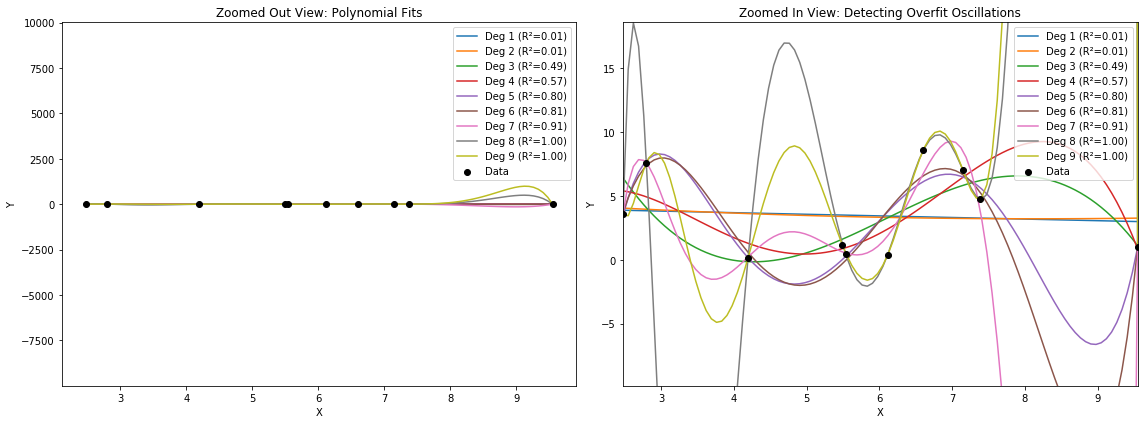

In [155]:
degrees = range(1, 10)

print(f"{'Degree':<8} | {'MSE':<12} | {'R-Squared':<10} | {'Status'}")
print("-" * 60)

#Plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
ax1.scatter(x_values, y_values, color="black", label="Data", zorder=9)
ax2.scatter(x_values, y_values, color="black", label="Data", zorder=9)

for d in degrees:

    #Fit polynomial
    coeffs = np.polyfit(x_values, y_values, d)
    poly = np.poly1d(coeffs)

    #Predictions
    y_pred = poly(x_values)

    #Metrics
    mse, r2 = metrics(y_values, y_pred)

    #Fitting status
    if r2 < 0.6:
        status = "Underfit"
    elif r2 < 0.85:
        status = "Reasonable"
    elif r2 < 0.98:
        status = "Good fit"
    else:
        status = "Overfit"

    print(f"{d:<8} | {mse:12.4f} | {r2:10.4f} | {status}")

    #Plot polynomial curves
    y_curve = poly(x_range)
    label = f"Deg {d} (R²={r2:.2f})"

    ax1.plot(x_range, y_curve, label=label)
    ax2.plot(x_range, y_curve, label=label)
#Graphing

#Zoomed out view to avoid clutter
ax1.set_title("Zoomed Out View: Polynomial Fits")
ax1.set_ylim(y_values.min() - 10000, y_values.max() + 10000)
ax1.set_xlabel("X")
ax1.set_ylabel("Y")
ax1.legend()

#Zoomed in view to highlight oscillations and why overfitting is bad
ax2.set_title("Zoomed In View: Detecting Overfit Oscillations")
ax2.set_xlim(x_values.min(), x_values.max())
ax2.set_ylim(y_values.min() - 10, y_values.max() + 10)
ax2.set_xlabel("X")
ax2.set_ylabel("Y")
ax2.legend()

plt.tight_layout()
plt.show()

In the code above, after zooming out, I can clearly see why the 9th degree polynomial was a major overfit, namely in how it oscillates in irregular patterns just so it can make contact with every data-point. I did have to look up on google how to make zoomed out views, and I used the google-ai response to get my information instead of stackoverflow or a different type of forum. 

# Challenge C

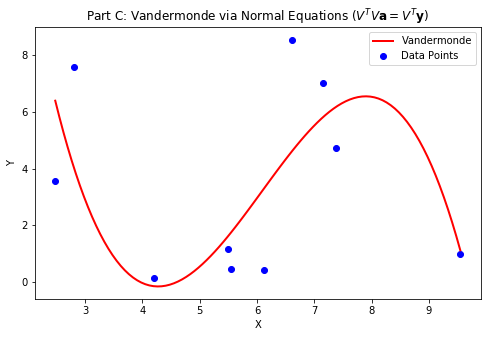

Vandermonde's Results: MSE: 4.9944, R2: 0.4910


In [154]:
degree_v = 3 

#Make Vandermonde matrix
V = np.vander(x_values, N=degree_v + 1, increasing=True)

# Solve equations
VT_V = np.dot(V.T, V)
VT_y = np.dot(V.T, y_values)
coeffs_vander = np.linalg.solve(VT_V, VT_y)

#Predict y-values for metrics
y_pred_vander = np.dot(V, coeffs_vander)
mse_vander, r2_vander = metrics(y_values, y_pred_vander)

#plotting values
V_plot = np.vander(x_range, N=degree_v + 1, increasing=True)
y_plot_vander = np.dot(V_plot, coeffs_vander)

#Graph
plt.figure(figsize=(8, 5))
plt.scatter(x_values, y_values, color='blue', label='Data Points')
plt.plot(x_range, y_plot_vander, color='red', linewidth=2, 
         label=f'Vandermonde')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Part C: Vandermonde via Normal Equations ($V^T V \mathbf{a} = V^T \mathbf{y}$)')
plt.legend()
plt.show()

print(f"Vandermonde's Results: MSE: {mse_vander:.4f}, R2: {r2_vander:.4f}")